<a href="https://colab.research.google.com/github/siddharthaggarwal25/Deep-learning-/blob/master/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

Saving placement.csv to placement (1).csv


In [ ]:
df = pd.read_csv("placement.csv")
print( df.head())

   cgpa  resume_score  placed
0  8.14          6.52       1
1  6.17          5.17       0
2  8.27          8.86       1
3  6.88          7.27       1
4  7.52          7.30       1


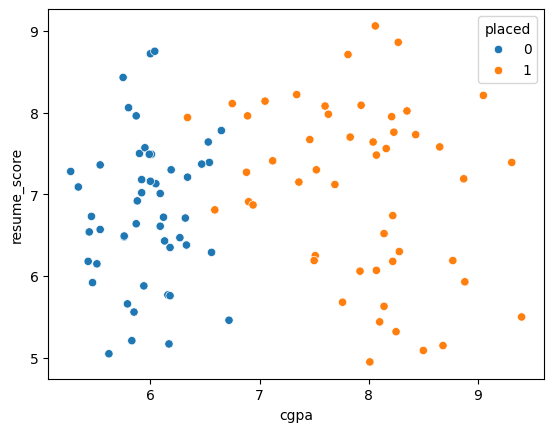

In [ ]:
sns.scatterplot(x="cgpa", y="resume_score", hue="placed"  , data = df)
plt.show()

In [ ]:
x = df.iloc[: , 0:2]
y = df.iloc[: , 2: 3]

In [ ]:
from sklearn.linear_model import Perceptron
p =Perceptron()


In [ ]:
p.fit(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Perceptron()

In [ ]:
p.coef_

array([[ 40.26, -36.  ]])

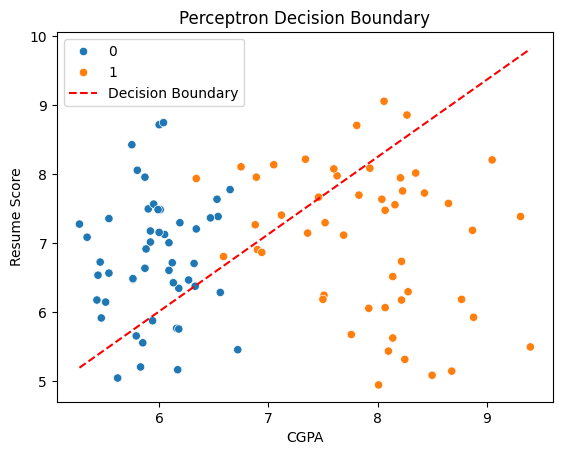

In [ ]:
w1 = p.coef_[0][0]
w2 = p.coef_[0][1]
b = p.intercept_[0]

# Calculate x1 (cgpa) values for the line
# We'll use the min and max cgpa values from the dataframe for the line's range
x1_min, x1_max = df['cgpa'].min(), df['cgpa'].max()
x1_line = np.array([x1_min, x1_max])

# Calculate x2 (resume_score) values using the decision boundary equation:
# w1*x1 + w2*x2 + b = 0  => x2 = (-w1*x1 - b) / w2
# Handle the case where w2 is zero to avoid division by zero or a vertical line
if w2 != 0:
    x2_line = (-w1 * x1_line - b) / w2
else:
    # If w2 is 0, the line is vertical: x1 = -b / w1
    x2_line = np.array([df['resume_score'].min(), df['resume_score'].max()]) # Span the full y-range
    x1_line = np.array([-b / w1, -b / w1]) # A constant x-value

# Plot the scatter plot again
sns.scatterplot(x="cgpa", y="resume_score", hue="placed", data=df)

# Plot the decision boundary line
plt.plot(x1_line, x2_line, color='red', linestyle='--', label='Decision Boundary')

plt.title('Perceptron Decision Boundary')
plt.xlabel('CGPA')
plt.ylabel('Resume Score')
plt.legend()
plt.show()